<a href="https://colab.research.google.com/github/hooveranna/symmetry_for_ML/blob/master/so3_6_S966_S25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab for `so3` exercsise for 6.S966 Spring 2025

In [1]:
%%capture
!rm symm4ml_obfuscated.zip
!wget -O symm4ml_obfuscated.zip https://symm4ml.mit.edu/_static/symm4ml_s25/symm4ml/symm4ml_obfuscated_20250312.zip
!unzip -o symm4ml_obfuscated.zip
import sys
sys.path.append('/content/symm4ml_obfuscated')

In [ ]:
%%capture
!pip install pymatgen

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import symm4ml
from symm4ml import groups, linalg, rep, vis, vib_modes, lie, so3, grids

# First, let's talk about $SO(3)$ Irreps

In [ ]:
so3_irreps = lie.infer_irreps_from_tensor_products(so3.so3_gens, 5)
# for ir in so3_irreps:
#     vis.plot_matrices(ir, figsize=(5, 2), cmap='RdBu')

### [Clebsch-Gordan Coefficients](https://en.wikipedia.org/wiki/Clebsch%E2%80%93Gordan_coefficients) articulate the change of basis between three irreps

#### Clebsch-Gordan Coefficients are only non-zero if the following inequality is satisfied
$|L_{\text{in1}} - L_{\text{in2}}| \leq L_{\text{out}}\leq L_{\text{in1}} + L_{\text{in1}}$

This equation articulates the "selection rules" of $SO(3)$.

<b>We shall call each nontrivial combination of $(L_{\text{in1}}, L_{\text{in2}}, L_{\text{out}})$ a "path"</b>.

For example, $(1, 2, 3)$ satisfies this equation but $(1, 2, 4)$ does not.

In [ ]:
L0, L1, L2, L3, L4 = so3_irreps[0], so3_irreps[1], so3_irreps[2], so3_irreps[3], so3_irreps[4]
cg_L1_L2_L3 = so3.clebsch_gordan(L1, L2, L3)
cg_L3_L2_L1 = so3.clebsch_gordan(L3, L2, L1)
cg_L2_L1_L3 = so3.clebsch_gordan(L2, L1, L3)
cg_L2_L1_L4 = so3.clebsch_gordan(L2, L1, L4)

In [ ]:
np.allclose(np.zeros_like(cg_L2_L1_L3), cg_L2_L1_L3)  # cg_L2_L1_L3 is NOT trivial

False

In [ ]:
np.allclose(np.zeros_like(cg_L2_L1_L4), cg_L2_L1_L4) # cg_L2_L1_L4 IS trivial

True

#### Clebsch-Gordan coefficients are equivariant under permtation of the two inputs, but not an input and output.

In [ ]:
# We can swap the inputs and arrive at the same change of basis
np.allclose(cg_L1_L2_L3, cg_L2_L1_L3.transpose(1, 0, 2))

True

In [ ]:
# But this is not the case if we permute an output wiht an input
np.allclose(cg_L1_L2_L3, cg_L3_L2_L1.transpose(2, 1, 0))

False

#### Clebsch-Gordan Coefficients are normalized such that the output over all possible <b>"paths"</b> will have unit norm for two inputs of unit norm.

For example, $1 \otimes 1 = 0 \oplus 1 \oplus 2$. Given two normalized inputs, we will recover a norm 1 output over all paths.

In [ ]:
cg_L1_L1_L0 = so3.clebsch_gordan(L1, L1, L0)
cg_L1_L1_L1 = so3.clebsch_gordan(L1, L1, L1)
cg_L1_L1_L2 = so3.clebsch_gordan(L1, L1, L2)
cg_L1_L1 = np.concatenate([cg_L1_L1_L0, cg_L1_L1_L1, cg_L1_L1_L2], axis=-1)

all_paths = np.einsum('ijk,i,j->k', cg_L1_L1, np.array([1, 0, 0]), np.array([0, 1, 0]))
print(np.linalg.norm(all_paths))

all_paths = np.einsum('ijk,i,j->k', cg_L1_L1, np.array([1, 0, 1] * 1 / np.sqrt(2)), np.array([1, 0, -1]) * 1 / np.sqrt(2))
print(np.linalg.norm(all_paths))

1.0000000000000002
0.9999999999999998


Note: [Wigner 3j symbol](https://en.wikipedia.org/wiki/3-j_symbol) are similar to Clebsch-Gordan coefficients, they just differ by normalization scheme. Wigner 3j symbols do not normalize for the output to preserve unit norm, but instead have the property that if we transpose the tensor product indices and arrive at the same values.


# Now, let's look at irreps of $O(3)$

### $O(3)$, the group of 3D rotoinversions, is a direct product group of 3D rotations and inversion, i.e. $O(3) = SO(3) \times Z_2$, which commute with each other.
Because of this, we know the irreps of this group are simple combinations of the irreps of the individual groups (Dresselhaus Ch 6.3). Thus, irreps are distinguished by two indices, $L$ from $SO(3)$ and parity $p$ which is either even (1) or odd (-1). We will also use the shorthand `Lp` to denote irreps of $O(3)$ which matches the convention in the [python library `e3nn`](https://e3nn.org/), developed by Prof. Smidt + the Atomic Architects + collaborators. :)

### Commonly known irreps of $O(3)$

* `0e`: A scalar, e.g. classification labels
* `0o`: A pseudoscalar, e.g. a "right" hand
* `1o`: A vector - angular frequency $L=1$ and flips under inversion e.g. 3D coordinates or forces
* `1e`: A pseudovector - angular frequency $L=1$ and does not flip under inversion, e.g. a rotation axis or a magnetic field

### While the $SO(3)$ parts of $O(3)$ forms a Lie group, $Z_2$ does not.
In order to determine how potentially reducible representations decompose into $O(3)$ irreps, we will use the representations (rather than generators) of this group. In cases where we need to "span" the entire group of $O(3)$, we can simply generate the matrix representations of $O(3)$ over random 3D rotoinversions.

In [ ]:
np.random.seed(42)
N = 10
rand_rots = np.random.rand(N, 3) * 2 * np.pi
rand_signs = np.array([1] * int(N/2) + [-1] * int(N/2))

o3_irreps = []
o3_irrep_labels = []
Lmax = 4
for L in range(Lmax+1):
    for p in [1, -1]:
        o3_irreps.append(so3.o3_irrep(so3_irreps[L], rand_rots, rand_signs, p))
        o3_irrep_labels.append("{L}{p}".format(L=L, p="e" if p==1 else "o"))

print(o3_irrep_labels)

['0e', '0o', '1e', '1o', '2e', '2o', '3e', '3o', '4e', '4o']


#### Because we are dealing with representations instead of generators, we go back to using functions from `rep` instead of `lie`.

In [ ]:
o3_1o = o3_irreps[o3_irrep_labels.index('1o')]
o3_1o_1o = rep.tensor_product(o3_1o, o3_1o)
o3_1o_1o_1o = rep.tensor_product(o3_1o_1o, o3_1o)
o3_1o_1o_1o_1o = rep.tensor_product(o3_1o_1o, o3_1o_1o)

## - $1o \otimes 1o$ to irreps

In [ ]:
cob = [linalg.infer_change_of_basis(ir, o3_1o_1o) for ir in o3_irreps]
print([(l, c.shape[0]) for l, c in zip(o3_irrep_labels, cob)])
print([c.shape[0] for c in cob])

[('0e', 1), ('0o', 0), ('1e', 1), ('1o', 0), ('2e', 1), ('2o', 0), ('3e', 0), ('3o', 0), ('4e', 0), ('4o', 0)]
[1, 0, 1, 0, 1, 0, 0, 0, 0, 0]


## - $1o \otimes 1o $ under symmetry `'ij=ji'` to irreps

In [ ]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ij=ji')
print(perm_rep)
print(sign_rep)

[[[1. 0.]
  [0. 1.]]

 [[0. 1.]
  [1. 0.]]]
[1. 1.]


Generate swaps on grid of values

In [ ]:
grid_rep = grids.perm_to_grid_rep(perm_rep, [3, 3])  # [3, 3] because order 2 cart tensor
grid_rep

array([[[1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1.]],

       [[1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1.]]])

Visualize swaps (labeling by first permutation element)

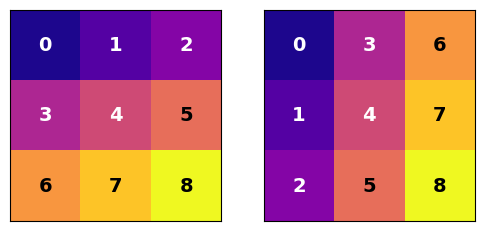

In [ ]:
vis.plot_image_values((grid_rep @ np.arange(3 * 3)).reshape(-1, 3, 3), (grid_rep @ np.arange(3 * 3)).reshape(-1, 3, 3), colormap="plasma", fontcolor=['white', 'black'], fontcolor_cutoff=4);

Compute subspace that tensor under permtation and sign indices lives in, change to that subspace and then `linalg.infer_change_of_basis` over irreps of $O(3)$

In [ ]:
new_basis, new_proj = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [3, 3])

sub = np.einsum('ij,njk,kl->nil', new_basis, o3_1o_1o, new_basis.T)
cob = [linalg.infer_change_of_basis(ir, sub) for ir in o3_irreps]
print([(l, c.shape[0]) for l, c in zip(o3_irrep_labels, cob)])
print([c.shape[0] for c in cob])

[('0e', 1), ('0o', 0), ('1e', 0), ('1o', 0), ('2e', 1), ('2o', 0), ('3e', 0), ('3o', 0), ('4e', 0), ('4o', 0)]
[1, 0, 0, 0, 1, 0, 0, 0, 0, 0]


## - $1o \otimes 1o \otimes 1o $ under symmetry `'ijk=jik=ikj'` to irreps

In [ ]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ijk=jik=ikj')
# Generates 6 elements
print(perm_rep)
print(sign_rep)

[[[0. 0. 1.]
  [0. 1. 0.]
  [1. 0. 0.]]

 [[0. 0. 1.]
  [1. 0. 0.]
  [0. 1. 0.]]

 [[0. 1. 0.]
  [0. 0. 1.]
  [1. 0. 0.]]

 [[0. 1. 0.]
  [1. 0. 0.]
  [0. 0. 1.]]

 [[1. 0. 0.]
  [0. 0. 1.]
  [0. 1. 0.]]

 [[1. 0. 0.]
  [0. 1. 0.]
  [0. 0. 1.]]]
[1. 1. 1. 1. 1. 1.]


In [ ]:
new_basis, new_proj = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [3, 3, 3])

sub = np.einsum('ij,njk,kl->nil', new_basis, o3_1o_1o_1o, new_basis.T)
cob = [linalg.infer_change_of_basis(ir, sub) for ir in o3_irreps]
print([(l, c.shape[0]) for l, c in zip(o3_irrep_labels, cob)])
print([c.shape[0] for c in cob])

[('0e', 0), ('0o', 0), ('1e', 0), ('1o', 1), ('2e', 0), ('2o', 0), ('3e', 0), ('3o', 1), ('4e', 0), ('4o', 0)]
[0, 0, 0, 1, 0, 0, 0, 1, 0, 0]


# Branching of irreps of $O(3)$ under subgroups

## Annoying group definition and reordering stuff

In [ ]:
try:
  from pymatgen.symmetry.groups import PointGroup
except:
  from pymatgen.symmetry.groups import PointGroup

### Matching [this $T_d$ character table](http://symmetry.jacobs-university.de/cgi-bin/group.cgi?group=902&option=4)

In [ ]:
Td_group = PointGroup(vib_modes.point_group_dict['Td'])
Td = np.stack([op.rotation_matrix for op in Td_group.symmetry_ops], axis=0)
Td_table = groups.make_multiplication_table(Td)
np.random.seed(42)
Td_irreps = rep.infer_irreps(Td_table)
Td_conj = groups.conjugacy_classes(Td_table)

Td_conj_reordered = [list(Td_conj)[i] for i in [1, 2, 3, 4, 0]]
Td_irreps_reordered = [Td_irreps[i] for i in [0, 2, 1, 4, 3]]
rep.character_table(Td_irreps_reordered, Td_conj_reordered).round(1).real

Td_irrep_labels = ['A1', 'A2', 'E', 'T1', 'T2']

rep.character_table(Td_irreps_reordered, Td_conj_reordered).round(2).real

array([[ 1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1., -1., -1.],
       [ 2., -1.,  2., -0., -0.],
       [ 3.,  0., -1.,  1., -1.],
       [ 3.,  0., -1., -1.,  1.]])

### Matching [this $C_{4v}$ character table](http://symmetry.jacobs-university.de/cgi-bin/group.cgi?group=404&option=4)

In [ ]:
C4v_group = PointGroup(vib_modes.point_group_dict['C4v'])
C4v = np.stack([op.rotation_matrix for op in C4v_group.symmetry_ops], axis=0)
C4v_table = groups.make_multiplication_table(C4v)
np.random.seed(42)
C4v_irreps = rep.infer_irreps(C4v_table)
C4v_conj = groups.conjugacy_classes(C4v_table)

C4v_conj_reordered = [list(C4v_conj)[i] for i in [-2, 0, 2, 4, 1]]
C4v_irreps_reordered = [C4v_irreps[i] for i in [0, 1, 3, 2, 4]]
rep.character_table(C4v_irreps_reordered, C4v_conj_reordered).round(1)

C4v_irrep_labels = ['A1', 'A2', 'B1', 'B2', 'E']

rep.character_table(C4v_irreps_reordered, C4v_conj_reordered).round(2).real

array([[ 1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1., -1., -1.],
       [ 1., -1.,  1.,  1., -1.],
       [ 1., -1.,  1., -1.,  1.],
       [ 2.,  0., -2., -0., -0.]])

### Matching [this $C_{2v}$ character table](http://symmetry.jacobs-university.de/cgi-bin/group.cgi?group=402&option=4)

In [ ]:
C2v_group = PointGroup(vib_modes.point_group_dict['C2v'])
C2v = np.stack([op.rotation_matrix for op in C2v_group.symmetry_ops], axis=0)
C2v_table = groups.make_multiplication_table(C2v)
np.random.seed(42)
C2v_irreps = rep.infer_irreps(C2v_table)
C2v_conj = groups.conjugacy_classes(C2v_table)

C2v_conj_reordered = [list(C2v_conj)[i] for i in [1, 0, 2, 3]]
C2v_irreps_reordered = [C2v_irreps[i] for i in [3, 2, 0, 1]]
rep.character_table(C2v_irreps_reordered, C2v_conj_reordered).round(1)

C2v_irrep_labels = ['A1', 'A2', 'B1', 'B2']

rep.character_table(C2v_irreps_reordered, C2v_conj_reordered).round(2).real

array([[ 1.,  1.,  1.,  1.],
       [ 1.,  1., -1., -1.],
       [ 1., -1.,  1., -1.],
       [ 1., -1., -1.,  1.]])

## Whew! Okay, now here's a helper function for Question 4 in the homework

In [ ]:
so3_irreps = lie.infer_irreps_from_tensor_products(so3.so3_gens, 5)

In [ ]:
def o3_branch(so3_irreps, sub, sub_irreps, sub_irrep_labels):
    rot_params, sign_params = so3.vec_3d_rep_to_rot_and_sign_params(sub)
    o3_irreps = [
        so3.o3_irrep(so3_irreps[i], rot_params, sign_params, parity=p) for i in range(len(so3_irreps)) for p in [1, -1]
    ]
    o3_irrep_labels = ["{L}{p}".format(L=L, p=p) for L in range(4) for p in ["e", "o"]]
    branch = vib_modes.branching_change_of_basis(o3_irreps, sub_irreps, np.arange(len(sub)))

    print('\t' + '\t\t'.join(sub_irrep_labels))
    for i, s_g in enumerate(o3_irrep_labels):
        print(o3_irrep_labels[i], "\t", "\t".join([str(branch[i][j].shape) for j, s_h in enumerate(sub_irrep_labels)]))

    return branch

## And here's how you can use it to see how irreps of $O(3)$ branch into irreps of the subgroup

In [ ]:
b = o3_branch(so3_irreps, Td, Td_irreps_reordered, Td_irrep_labels)

	A1		A2		E		T1		T2
0e 	 (1, 1, 1)	(0, 1, 1)	(0, 2, 1)	(0, 3, 1)	(0, 3, 1)
0o 	 (0, 1, 1)	(1, 1, 1)	(0, 2, 1)	(0, 3, 1)	(0, 3, 1)
1e 	 (0, 1, 3)	(0, 1, 3)	(0, 2, 3)	(1, 3, 3)	(0, 3, 3)
1o 	 (0, 1, 3)	(0, 1, 3)	(0, 2, 3)	(0, 3, 3)	(1, 3, 3)
2e 	 (0, 1, 5)	(0, 1, 5)	(1, 2, 5)	(0, 3, 5)	(1, 3, 5)
2o 	 (0, 1, 5)	(0, 1, 5)	(1, 2, 5)	(1, 3, 5)	(0, 3, 5)
3e 	 (0, 1, 7)	(1, 1, 7)	(0, 2, 7)	(1, 3, 7)	(1, 3, 7)
3o 	 (1, 1, 7)	(0, 1, 7)	(0, 2, 7)	(1, 3, 7)	(1, 3, 7)


# Spherical Harmonics from tensor products

Compare to [Real Spherical Harmonics](https://en.wikipedia.org/wiki/Table_of_spherical_harmonics#Real_spherical_harmonics)

Really should do this with symmmetric tensor constraints e.g. `1ox1o` wiht `ij=ji` -- but in practice don't need to because we can always just "skim off the top", i.e. take the largest irrep. from outer product of $n$ vectors.

<b>TODO: Write a function that given these change of basis prints a nice set of polynomials.</b>

## Compute change of basis between tensor product generators. $(L=1) \otimes (L=1) = (L=2)$

## Because of the properties of similarity transforms below, we can simply reshape to get the Clebsch-Gordan coefficients
$U e^{X}U^{-1} = e^{UXU^{-1}}$

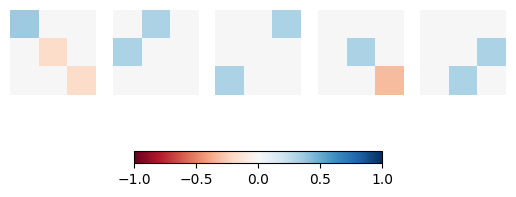

In [ ]:
cob = linalg.infer_change_of_basis(o3_1o_1o, o3_irreps[4])
cob.shape

vis.plot_matrices(np.einsum('ijk->kij', cob.reshape(3, 3, 5)), cmap='RdBu');

In [ ]:
import sympy as sp
import numpy as np

tensor = np.einsum('ijk->kij', cob.reshape(3, 3, 5)).round(3)

# Define symbols
x, y, z = sp.symbols('x y z')

# Build the polynomial
poly_expr = 0
vars = [x, y, z]
for t in tensor:
  poly_expr = 0
  for i, xi in enumerate(vars):
      for j, xj in enumerate(vars):
            poly_expr += t[i, j] * xi * xj
  poly_expr = sp.expand(poly_expr)
  print(poly_expr)

# Expand for readability

0.365*x**2 - 0.183*y**2 - 0.183*z**2
0.632*x*y
0.632*x*z
0.316*y**2 - 0.316*z**2
0.632*y*z


## The 5 polynomials that transform as $L=2$ (reading from left to right and neglecting normalization for now are) are
$2x_1 x_2 - y_1 y_2 - z_1 z_2\\
x_1 y_2 + y_1 x_2 \\
x_1 z_2 + z_1 x_2 \\
y_1 y_2 - z_1 z_2 \\
y_1 z_2 + z_1 y_2$

## Or if ${\vec{x_1} = \vec{x_2}}$

$\{2x^2 - y^2 - z^2, xy, zx, y^2 - z^2, yz\}$

These are a valid choice of $L=2$ spherical harmonics. (You can see that they are similar to those [here](https://en.wikipedia.org/wiki/Table_of_spherical_harmonics#Real_spherical_harmonics) up to a change of basis)

Do same for $1o\otimes 1o \otimes 1o = 3o$. Note that the matrices are symmetric! (We can contract change of basis with same vector and get something non-trivial)

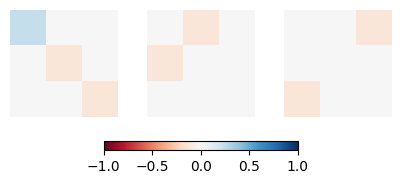

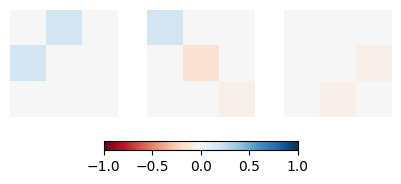

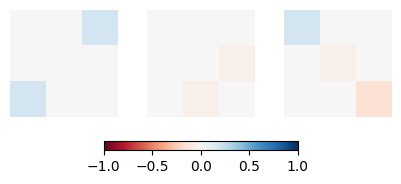

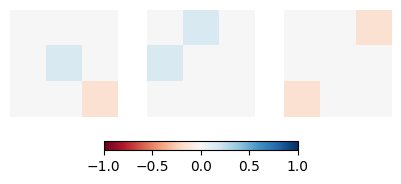

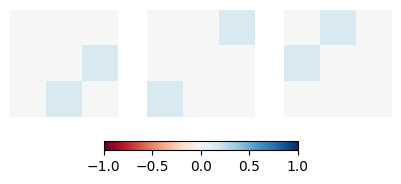

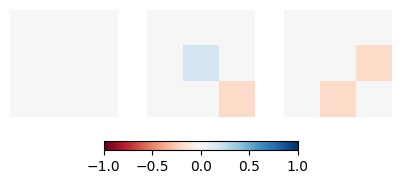

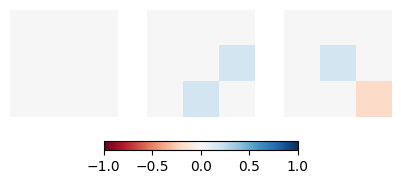

In [ ]:
cob = linalg.infer_change_of_basis(o3_1o_1o_1o, o3_irreps[7])
cob.shape

cob_reshape = np.einsum('ijkl->lijk', cob.reshape(3, 3, 3, 7))
for i in range(7):
  vis.plot_matrices(cob_reshape[i], cmap='RdBu', figsize=(5, 2));

In [ ]:
import sympy as sp
import numpy as np

tensor = np.einsum('ijkl->lijk', cob.reshape(3, 3, 3, 7)).round(3)

# Define symbols
x, y, z = sp.symbols('x y z')

# Build the polynomial
poly_expr = 0
vars = [x, y, z]
for t in tensor:
  poly_expr = 0
  for i, xi in enumerate(vars):
      for j, xj in enumerate(vars):
          for k, xk in enumerate(vars):
              poly_expr += t[i, j, k] * xi * xj * xk
  poly_expr = sp.expand(poly_expr)
  print(poly_expr)

# Expand for readability

0.239*x**3 - 0.36*x*y**2 - 0.36*x*z**2
0.585*x**2*y - 0.146*y**3 - 0.147*y*z**2
0.585*x**2*z - 0.147*y**2*z - 0.146*z**3
0.462*x*y**2 - 0.462*x*z**2
0.924*x*y*z
0.189*y**3 - 0.567*y*z**2
0.567*y**2*z - 0.189*z**3
